In [1]:
import pandas as pd
import gdown
# import pickle

#https://drive.google.com/file/d/1e60rJl23wgVkjgV7YnymWjYQ2i0evjSM/view?usp=drive_link

# 1. Determine the url to import
file_id = '1e60rJl23wgVkjgV7YnymWjYQ2i0evjSM'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file locally
output_file = 'data/02-processed/data_compat.parquet'
gdown.download(url, output_file, quiet=False)

# 3. Read file & reconstruct the original dict structure
df = pd.read_parquet('data/02-processed/data_compat.parquet')

reviews = {app_id: group.drop(columns='app_id').set_index('review_id') 
        for app_id, group in df.groupby('app_id')}

Downloading...
From: https://drive.google.com/uc?id=1e60rJl23wgVkjgV7YnymWjYQ2i0evjSM
To: /home/bbothello/private/Group-SP26-089/data/02-processed/data_compat.parquet
100%|██████████| 91.0M/91.0M [00:01<00:00, 83.0MB/s]


In [2]:
print(reviews[10])

           timestamp_created  voted_up
review_id                             
226667535               2026      True
226654116               2026      True
226649202               2026      True
226632276               2026      True
226609263               2026      True
...                      ...       ...
124005315               2022      True
124004901               2022      True
123990500               2022      True
123989586               2022      True
123965645               2022      True

[10000 rows x 2 columns]


In [3]:
our_tags = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'Strategy', '2D', '3D']


In [4]:
data = pd.read_csv("steam_games_2026_cleaned.csv")
data.head()
data.columns

Index(['AppID', 'Release_Date', 'Name', 'All_Tags', 'Review_Score_Pct',
       'Total_Reviews'],
      dtype='object')

In [5]:
tags_list = data['All_Tags'].values.tolist()

i = 0
for x in tags_list:
    tags_list[i] = x.split(';')
    tags_list[i] = tags_list[i][:3]
    i += 1

data['Top_3_Tags'] = tags_list

In [6]:
#Cut down data to only ones which is within the top ten tags
top_data = data[data.apply(lambda x: (any(substring in x['All_Tags'] for substring in our_tags)), axis=1)]
top_three_data = data[data.apply(lambda x: (any(substring in x['Top_3_Tags'] for substring in our_tags)), axis=1)]
print(len(top_data))
print(len(data))
print(len(top_three_data))


5127
5417
3114


In [7]:
ind_tag_data = pd.DataFrame(columns=['tag_name', 'review_score'])

for tag_name in our_tags:
    for index, row in data.iterrows():
        if (tag_name in row['All_Tags']):
            ind_tag_data.loc[len(ind_tag_data)] = [tag_name, row['Review_Score_Pct']]
            

In [8]:
ind_tag_data.head()

,tag_name,review_score
0,Indie,88
1,Indie,31
2,Indie,98
3,Indie,92
4,Indie,86


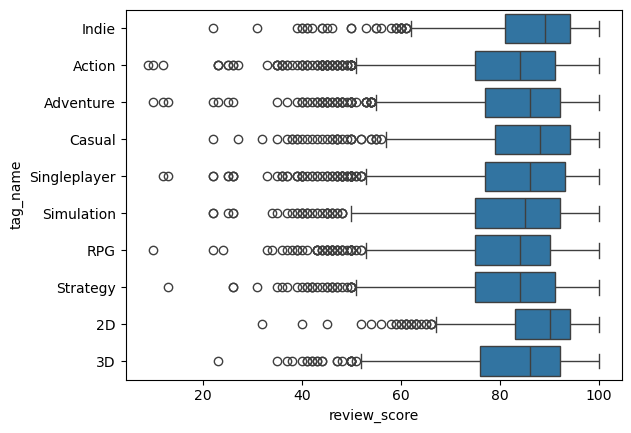

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y="tag_name", x="review_score", data=ind_tag_data)

plt.show()

In [10]:
top_data_tags = pd.DataFrame(columns=['tag_name', 'review_score'])

for tag_name in our_tags:
    for index, row in data.iterrows():
        if (tag_name in row['Top_3_Tags']):
            top_data_tags.loc[len(top_data_tags)] = [tag_name, row['Review_Score_Pct']]
            

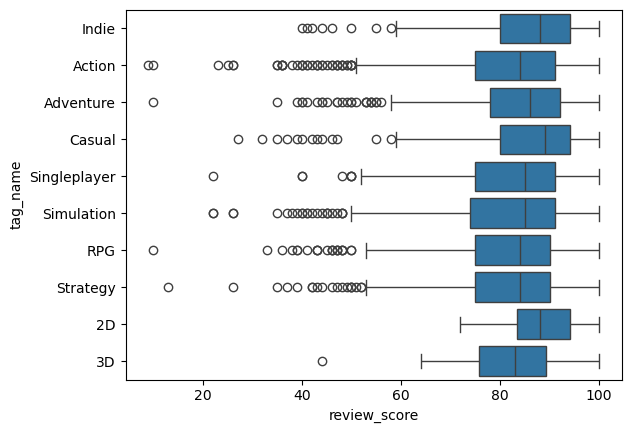

In [11]:
sns.boxplot(y="tag_name", x="review_score", data=top_data_tags)

plt.show()

In [12]:
avg_per_per_tag = pd.DataFrame(columns=["tag_name", "avg"]) 

for tag_name in our_tags:
    sum_of_avgs = 0
    num_of_games = 0
    for index, row in data.iterrows():
        if (tag_name in row['All_Tags']):
            sum_of_avgs += row['Review_Score_Pct']
            num_of_games += 1
    avg_per_per_tag.loc[len(avg_per_per_tag)] = [tag_name, sum_of_avgs / num_of_games]

print(avg_per_per_tag.head())

       tag_name        avg
0         Indie  86.065744
1        Action  81.283122
2     Adventure  83.202658
3        Casual  84.516332
4  Singleplayer  83.313835


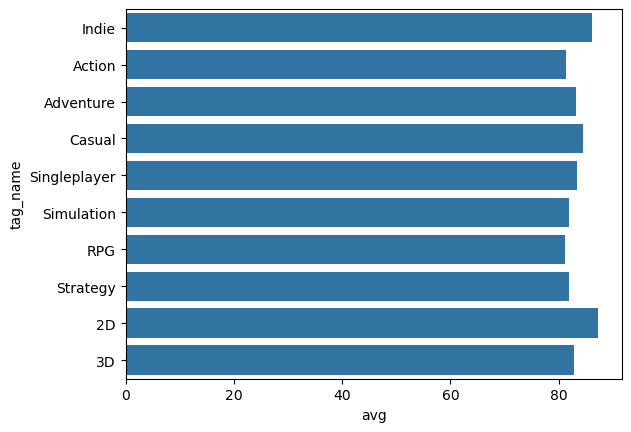

In [13]:
sns.barplot(data=avg_per_per_tag, y="tag_name", x='avg')
plt.show()

In [14]:
three_avg = pd.DataFrame(columns=["tag_name", "avg"]) 

for tag_name in our_tags:
    sum_of_avgs = 0
    num_of_games = 0
    for index, row in data.iterrows():
        if (tag_name in row['Top_3_Tags']):
            sum_of_avgs += row['Review_Score_Pct']
            num_of_games += 1
    three_avg.loc[len(three_avg)] = [tag_name, sum_of_avgs / num_of_games]

print(three_avg.head())


       tag_name        avg
0         Indie  85.406375
1        Action  80.613277
2     Adventure  83.581709
3        Casual  85.297468
4  Singleplayer  82.189474


In [15]:
three_avg['ten_avg'] = avg_per_per_tag['avg']
three_avg.head()

,tag_name,avg,ten_avg
0,Indie,85.406375,86.065744
1,Action,80.613277,81.283122
2,Adventure,83.581709,83.202658
3,Casual,85.297468,84.516332
4,Singleplayer,82.189474,83.313835


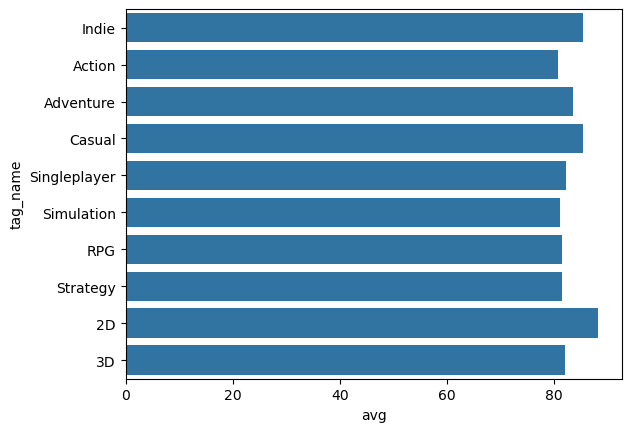

In [16]:
sns.barplot(data=three_avg, y="tag_name", x='avg')
plt.show()

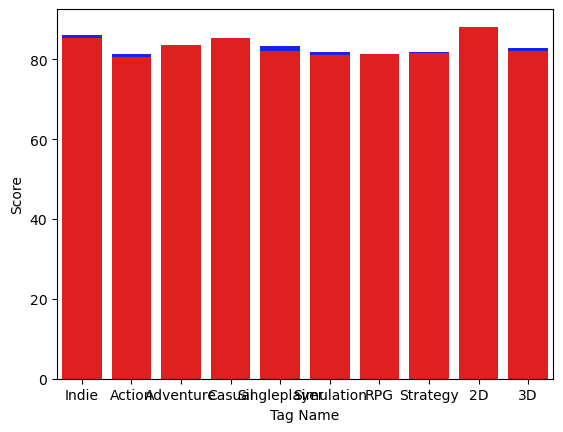

In [17]:
ax = plt.subplots()

# plotting columns
ax = sns.barplot(x=three_avg["tag_name"], y=three_avg["ten_avg"], color='b')
ax = sns.barplot(x=three_avg["tag_name"], y=three_avg["avg"], color='r')

# renaming the axes
ax.set(xlabel="Tag Name", ylabel="Score")

# visualizing illustration
plt.show()

In [18]:
import numpy as np

In [19]:
#Import df from the game review dictionary
counts = reviews[10]

print(counts.columns)
print(counts['timestamp_created'] == '2022')

print(counts.groupby('timestamp_created')['voted_up'].value_counts()[2023])
print((counts['timestamp_created'] == 2023).any())

Index(['timestamp_created', 'voted_up'], dtype='object')
review_id
226667535    False
226654116    False
226649202    False
226632276    False
226609263    False
             ...  
124005315    False
124004901    False
123990500    False
123989586    False
123965645    False
Name: timestamp_created, Length: 10000, dtype: bool
voted_up
True     2932
False     109
Name: count, dtype: int64
True


In [20]:
def CreateDataForGame(row, rank_num):

    #See if the game is in the dictionary
    if int(row['AppID']) not in reviews.keys():
        #print("not in dict")
        return np.NaN
        
    #Import df from the game review dictionary
    counts = reviews[int(row['AppID'])]
    
    #Get the year index
    #years = list(set(counts.index.get_level_values(0)))
    #years = list(map(str, years))
    #year_ratings = {}

    #Initialize series
    game_series = pd.Series({"appID": row['AppID']})

    #print(years)

    for i in range(10, 27):
        year_str = "20" + str(i)
        year_int = 2000 + i
        if (counts['timestamp_created'] == year_int).any():
            #year_ratings.update({year_str: counts[year_str]})
            game_series.loc[year_str + "_Ratings"] = counts.groupby('timestamp_created')['voted_up'].value_counts()[year_int]
            #print("adding to series")

    return game_series

In [21]:
def AddGameToTag(tag, data):
    if tag not in tag_dict:
        tag_dict[tag] = pd.DataFrame()
    tag_dict[tag] = pd.concat([tag_dict[tag], data.to_frame().T], ignore_index=True)

In [22]:
print(ind_tag_data.columns)

Index(['tag_name', 'review_score'], dtype='object')


In [23]:
tag_dict = {}
for index, row in data.iterrows():
    tag_series = row['All_Tags'].split(';')
    rankNum = 1
    for tag in tag_series:
        if not(tag in our_tags):
            continue
        test_game = CreateDataForGame(row, rankNum)
        if test_game is not np.NaN:
            AddGameToTag(tag, test_game)
            rankNum += 1
        else:
            break

In [24]:
tag_dict["Indie"]

,appID,2023_Ratings,2024_Ratings,2025_Ratings,2026_Ratings,2021_Ratings,2022_Ratings,2016_Ratings,2017_Ratings,2018_Ratings,2019_Ratings,2020_Ratings,2015_Ratings,2014_Ratings,2013_Ratings,2012_Ratings,2011_Ratings,2010_Ratings
0,848450,voted_up True 2697 False 375 Name: cou...,voted_up True 4184 False 674 Name: cou...,voted_up True 3084 False 600 Name: cou...,voted_up True 2002 False 384 Name: cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2868840,NaN,NaN,NaN,voted_up True 12487 False 1513 Name: c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,220200,NaN,voted_up True 2783 False 79 Name: cou...,voted_up True 4527 False 148 Name: cou...,voted_up True 6351 False 112 Name: cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1809540,NaN,voted_up True 5082 False 179 Name: cou...,voted_up True 6541 False 380 Name: cou...,voted_up True 1707 False 111 Name: cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3100370,NaN,NaN,NaN,voted_up True 328 False 23 Name: count...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860,617670,voted_up True 433 False 16 Name: count...,voted_up True 301 False 18 Name: count...,voted_up True 303 False 14 Name: count...,voted_up True 143 False 11 Name: count...,voted_up True 597 False 7 Name: count...,voted_up True 479 False 15 Name: count...,NaN,NaN,"voted_up True 51 False 2 Name: count, ...",voted_up True 210 False 3 Name: count...,voted_up True 358 False 15 Name: count...,NaN,NaN,NaN,NaN,NaN,NaN
861,484900,"voted_up True 44 False 31 Name: count, ...","voted_up True 59 False 29 Name: count, ...","voted_up True 36 False 24 Name: count, ...","voted_up True 15 False 8 Name: count, ...",voted_up True 151 False 31 Name: count...,"voted_up True 89 False 34 Name: count, ...",NaN,voted_up True 152 False 75 Name: count...,"voted_up True 93 False 28 Name: count, ...","voted_up True 73 False 23 Name: count, ...",voted_up True 169 False 38 Name: count...,NaN,NaN,NaN,NaN,NaN,NaN
862,2501600,NaN,voted_up True 784 False 27 Name: count...,voted_up True 569 False 35 Name: count...,"voted_up True 65 False 7 Name: count, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
863,2430730,"voted_up True 53 Name: count, dtype: int64",voted_up True 194 False 6 Name: count...,voted_up True 142 False 4 Name: count...,"voted_up True 34 False 3 Name: count, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
import pickle
with open('top_tags.pkl', 'wb') as file:
    pickle.dump(tag_dict, file)

In [26]:
def GetPercentForYear(col):
    #Initialize vars
    total_percent_sum = 0
    num_reviews_added = 0
    series_index = 0
    #Add the percentage for each game in the tag
    for game in col:
        #Conditional to ignore if the game doesn't have reviews for this year (would be np.NaN)
        if type(col[series_index]) is pd.Series:

            #Get the number of positive reviews for the game that year
            if True in col[series_index].index:
                num_pos = col[series_index].loc[True]
            else:
                num_pos = 0

            #Get the number of negatibe reviews for the game that year
            if False in col[series_index].index:
                num_neg = col[series_index].loc[False]
            else:
                num_neg = 0
            
            #Calculate the decimal percentage for this game this year
            if (num_pos != 0) or (num_neg != 0):         
                total_percent_sum += (num_pos / (num_pos + num_neg))
                num_reviews_added += 1
        series_index += 1
    #If there is at least one review percentage for this tag, calculate the average percent for this year
    if num_reviews_added != 0:
        return (total_percent_sum / num_reviews_added)
    else:
        return np.NaN

In [27]:
# 1. Determine the url to import
file_id = '19i1sAJ4Rj8aMwt7dF0iQaBRb8a3YgMfQ'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file locally
output_file = 'downloaded_model.pkl'
gdown.download(url, output_file, quiet=False)

# 3. Load the downloaded pickle file
with open(output_file, 'rb') as file:
    new_tag_dict = pickle.load(file)

Downloading...
From (original): https://drive.google.com/uc?id=19i1sAJ4Rj8aMwt7dF0iQaBRb8a3YgMfQ
From (redirected): https://drive.google.com/uc?id=19i1sAJ4Rj8aMwt7dF0iQaBRb8a3YgMfQ&confirm=t&uuid=1aee3277-bac8-4c4b-9fae-6f28a489a75f
To: /home/bbothello/private/Group-SP26-089/downloaded_model.pkl
100%|██████████| 206M/206M [00:02<00:00, 91.7MB/s] 


In [28]:
# 3. Load the downloaded pickle file
with open(output_file, 'rb') as file:
    new_tag_dict = pickle.load(file)

In [29]:
#Test call
#print(tag_dict['FPS']['2026_Ratings'])
#print(new_tag_dict['FPS']['2026_Ratings'])

#print(tag_dict['Indie'])
#print(True in col[series_index].index)

In [30]:
#Function to get the percentages per year for a tag
def GetPercentages(tag):
    year_dict = {}
    for i in range(10, 27):
        year_str = "20" + str(i)
        year_int = 2000 + i
        # print(year_str)
        year_dict.update({year_int: GetPercentForYear(tag[year_str + '_Ratings'])})
        if (counts['timestamp_created'] == int(year_str)).any():
            print(year_str)
            #year_dict.update({year_int: GetPercentForYear(tag[year_str + '_Ratings'])})
    
    return year_dict

def GetPercentForYear(col):
    #Initialize vars
    total_percent_sum = 0
    num_reviews_added = 0
    series_index = 0
    #Add the percentage for each game in the tag
    for game in col:
        #Conditional to ignore if the game doesn't have reviews for this year (would be np.NaN)
        if type(col[series_index]) is pd.Series:
            #print("got here")
            #Get the number of positive reviews for the game that year
            if True in col[series_index].index:
                num_pos = col[series_index].loc[True]
                #print(num_pos)
            else:
                num_pos = 0

            #Get the number of negatibe reviews for the game that year
            if False in col[series_index].index:
                num_neg = col[series_index].loc[False]
            else:
                num_neg = 0
            
            #Calculate the decimal percentage for this game this year
            if (num_pos != 0) or (num_neg != 0):         
                total_percent_sum += (num_pos / (num_pos + num_neg))
                num_reviews_added += 1
        series_index += 1
    #If there is at least one review percentage for this tag, calculate the average percent for this year
    if num_reviews_added != 0:
        return (total_percent_sum / num_reviews_added)
    else:
        return np.NaN

In [31]:
#Create a dataframe for the tags and their yearly percent averages
cols = ['Tag', 'Year', 'Rating']
df = pd.DataFrame(columns=cols)

#List the top ten tags to analyze
top_ten = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'RPG', '2D', '3D']

# print(GetPercentages(tag_dict["Indie"]).keys())

#Add each average percentage for each tag per year
for tag in top_ten:
    year_dict = GetPercentages(tag_dict[tag])
    for dict_key in year_dict.keys():
        df.loc[len(df)] = [tag, dict_key, year_dict[dict_key]]


#Verify data
print(df)

2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
       Tag  Year    Rating
0    Indie  2010  0.993590
1    Indie  2011  0.971050
2    Indie  2012  0.962334
3    Indie  2013  0.934483
4    Indie  2014  0.902652
..     ...   ...       ...
165     3D  2022  0.861226
166     3D  2023  0.859252
167     3D  2024  0.842229
168     3D  2025  0.836901
169     3D  2026  0.824255

[170 rows x 3 columns]


[Text(0.5, 0, 'Year'),
 Text(0, 0.5, 'Average Rating'),
 Text(0.5, 1.0, 'Top 10 Steam Tags Average Rating By Year')]

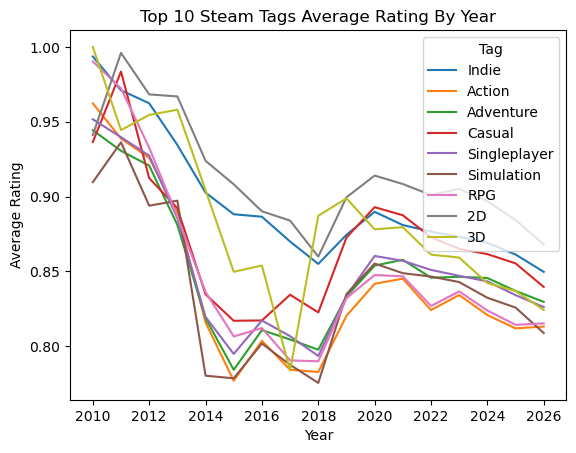

In [32]:
f1 = sns.lineplot(df, x = 'Year', y = 'Rating', hue = 'Tag')
f1.set(xlabel="Year", ylabel="Average Rating", title="Top 10 Steam Tags Average Rating By Year")

In [33]:
our_tags = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'Strategy', '2D', '3D']
import gdown
import pickle
#https://drive.google.com/file/d/1kaRt4d7sB_SmdzCnLLcQOwNLFhXcQrq4/view?usp=drive_link
# 1. Determine the url to import
file_id = '1kaRt4d7sB_SmdzCnLLcQOwNLFhXcQrq4'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file locally
output_file = 'downloaded_model.pkl'
gdown.download(url, output_file, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1kaRt4d7sB_SmdzCnLLcQOwNLFhXcQrq4
To: /home/bbothello/private/Group-SP26-089/downloaded_model.pkl
0.00B [00:00, ?B/s]


'downloaded_model.pkl'

In [34]:

# 3. Load the downloaded pickle file
with open('top_tags.pkl', 'rb') as file:
    new_tag_dict = pickle.load(file)

In [35]:
import pandas as pd
import numpy as np

#Create a dataframe for the tags and their yearly percent averages
cols = ['Tag', 'Year', 'Rating']
df = pd.DataFrame(columns=cols)

#List the top ten tags to analyze
top_ten = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'Strategy', '2D', '3D']

# print(GetPercentages(tag_dict["Indie"]).keys())

#Add each average percentage for each tag per year
for tag in top_ten:
    year_dict = GetPercentages(new_tag_dict[tag])
    for dict_key in year_dict.keys():
        df.loc[len(df)] = [tag, dict_key, year_dict[dict_key]]


#Verify data
print(df)

2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
2022
2023
2024
2025
2026
       Tag  Year    Rating
0    Indie  2010  0.993590
1    Indie  2011  0.971050
2    Indie  2012  0.962334
3    Indie  2013  0.934483
4    Indie  2014  0.902652
..     ...   ...       ...
165     3D  2022  0.861226
166     3D  2023  0.859252
167     3D  2024  0.842229
168     3D  2025  0.836901
169     3D  2026  0.824255

[170 rows x 3 columns]


[Text(0.5, 0, 'Year'),
 Text(0, 0.5, 'Average Rating'),
 Text(0.5, 1.0, 'Top 10 Steam Tags Average Rating By Year')]

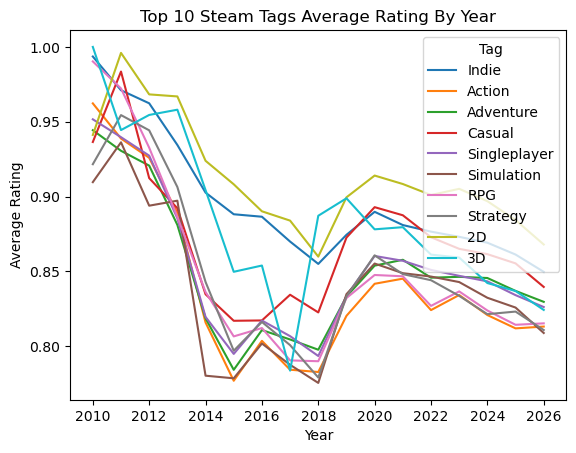

In [36]:
f1 = sns.lineplot(df, x = 'Year', y = 'Rating', hue = 'Tag')
f1.set(xlabel="Year", ylabel="Average Rating", title="Top 10 Steam Tags Average Rating By Year")